#### Name: Kristen Townsend

# PHYS 230 Lab Assignment 9

### Monday, February 23, 2026: Chapter 5.5-5.9
- Evaluating integrals in python 
    - Gaussian Quadrature 
    - Infinite integrals
    - Multiple integrals

***Don't forget to include comments in your code and a final markdown explanation at the end of each problem.***

In [10]:
# put all import statements here
import numpy as np
from gaussxw import gaussxw
import matplotlib.pyplot as plt

## Gaussian Quadrature 1 (22 pts)

Consider the integral from last lab $$\int_{1.1}^{10.1} \frac{\sin{x}}{\ln{x}} \,dx $$ a) Re-evaulate the integral using Gaussian quadrature with 𝑁=10 points 

b) Repeat the evaluation with 2𝑁 points and evaluate the error.  

c) Compare these results with your results for both the trapezoidal and Simpson’s rules


In [5]:
# part a
def f(x):
    return np.sin(x) / np.log(x)

# define our constants
a = 1.1
b = 10.1
N = 10

x, w = gaussxw(N)

# map to required integration domain
xk = 0.5*(b-a)*x + 0.5*(b+a)
wk = 0.5*(b-a)*w

# apply gaussian quadrature
s = 0.0
for k in range(N):
    s+= wk[k] * f(xk[k])

print("The result of GQ is", s)

The result of GQ is 2.7929415637242574


Defined the function and imported numpy.
Imported gaussxw.py.
Followed code completed in class. 
Used the gaussxw function to find the sample points and the associated weights. Mapped these points to the domain using $x'_k = \frac{1}{2}(b-a)x_k + \frac{1}{2}(b+a)$ and $w'_k = \frac{1}{2}(b-a)w_k$.

In [ ]:
# part b
N = 20 # 2N

x, w = gaussxw(N)

# map to required integration domain
xk = 0.5*(b-a)*x + 0.5*(b+a)
wk = 0.5*(b-a)*w

# apply gaussian quadrature
s2 = 0.0
for k in range(N):
    s2 += wk[k] * f(xk[k])

# calculating error
delta = np.abs(s2 - s)
print("Error estimation for GQ is", delta)

2.84805880772841
Error estimation for GQ is 0.05511724400415252


Changed N to 20 and followed the same process as part a. Calculated the error by finding the absolute value of the difference between the two results.

In [9]:
# part c
# past results
trap_result = 2.8628779013854735
simp_result = 2.856855482008929

# finding error
delta_tq = np.abs(s2 - trap_result)
delta_sq = np.abs(s2 - simp_result)

print("The calculated error between GQ and Trapezoidal is", delta_tq)
print("The calculated error between GQ and Simpson's is", delta_sq)

The calculated error between GQ and Trapezoidal is 0.014819093657063576
The calculated error between GQ and Simpson's is 0.008796674280519223


Found the results from the last lab for the trapezoidal and simpson's estimation. If we assume the gaussian quadrature to be the most accurate value, simpson's has the closest estimation. Trapezoidal seems to be pretty innacurate.

## Gaussian Quadrature 2 (22 pts)

One of the caveats of Gaussian Quadrature is that the function being integrated must be relatively smooth. With this in mind, let’s integrate the function $$ f(x) = e^{-x^2/2}$$ from 𝑥=0 to 𝑥=1.5 using 2 sample points. 


a) First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

b) Determine and print out the values of the sample points and weights for this problem. 
Evaluate the integral. 

c) Double the number of sample points and apply parts (b) and (c) until your error is less than our desired accuracy of $10^{−5}$


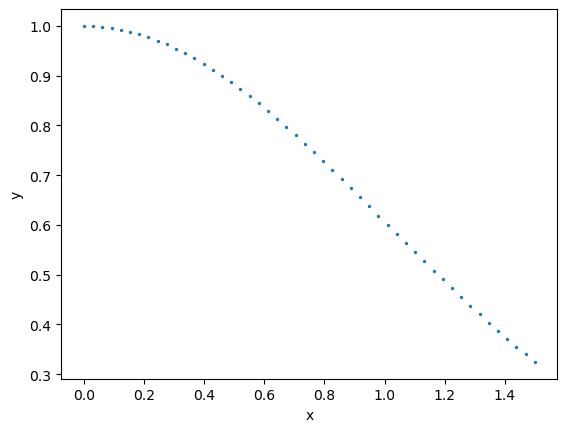

In [12]:
# part a
# define the function
def f(x):
    return np.exp(-x**2 / 2)

# defining constants
a = 0
b = 1.5

# create an array for x values with 50 points
x_vals = np.linspace(a, b, 50)

# create an array of y values
y_vals = []
for x in x_vals:
    y_vals.append(f(x))
y_vals = np.array(y_vals)

# make the plot
plt.scatter(x_vals, y_vals, s=2)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


Need to make a plot? Import matplotlib.pyplot! I defined a function for the equation $f(x) = e^{-x^2/2}$. I then created an array of 50 evenly spaced values between $a=0$ and $b=1.5$. I created an array of y values by first initializing an empty list and gradually appending values of from the function for every number in the array of x values. Once all of the x values had been run through the function and appended to the list of y values, the list was converted into an array to be used in a plot. A scatter plot.

The function seems smooth to me? The GQ method should be accurate.

In [16]:
# part b
# constants
N = 2

x, w = gaussxw(N)

# map to required integration domain
xk = 0.5*(b-a)*x + 0.5*(b+a)
wk = 0.5*(b-a)*w

print("The sample points are:",xk)
print("The weights are:",wk)

# apply gaussian quadrature
s = 0.0
for k in range(N):
    s+= wk[k] * f(xk[k])

print("The result of GQ is", s)

The sample points are: [1.1830127 0.3169873]
The weights are: [0.75 0.75]
The result of GQ is 1.0857790801898561


2 points doesn't seem very accurate. 

I used the gaussxw function to find the sample points and the associated weights. Mapped these points to the domain using $x'_k = \frac{1}{2}(b-a)x_k + \frac{1}{2}(b+a)$ and $w'_k = \frac{1}{2}(b-a)w_k$. I then applied GQ with a summation of $w'_k f(x'_k)$ for every data point N.

In [24]:
# part c
# control the while loop
runCalc = True

# constants
a = 0
b = 1.5
N = 2

# take value from part b
s1 = s

while runCalc:
    N *= 2

    x, w = gaussxw(N)

    # map to required integration domain
    xk = 0.5*(b-a)*x + 0.5*(b+a)
    wk = 0.5*(b-a)*w

    # apply gaussian quadrature
    s2 = 0.0
    for k in range(N):
        s2+= wk[k] * f(xk[k])

    # calculate errors
    delta = np.abs(s2-s1)
    
    # setting values for the next error calc
    s1 = s2

    # conditional to break the loop
    if delta <= 1e-5:
        runCalc = False


print("Number of points:",N)



Number of points: 8


I decided to find this using a while loop. Bulk of the code is the same from part b. Included a conditional that, when fulfilled, would stop the while loop from continuing so the resulting number of points can be printed. To calculate the error I set the value calculated in the last iteration of the loop equal to the new value calculated so it can serve as the "old value" for the next loop. The value of N was doubled each loop.

## Gaussian Quadrature 3 (22 pts)

Apply the method of Gaussian Quadrature to integrate the function $$f(x) = \sin\left(\frac{1}{x}\right)$$ from $𝑥=0.01$ to $x = 2\pi$. Do so in the via the following steps: 

a)  First, make a plot of $f(x)$ vs. $x$ for 50 points within the limits of integration. Is this function smooth? Do we expect the method of GQ to return an accurate result? 

b) Start with $N=5$ sample points & use a `while` loop to continue doubling $N$ until you achieve the accuracy you want (maybe $10^{-5}$). Comment on what happens each time you double. 


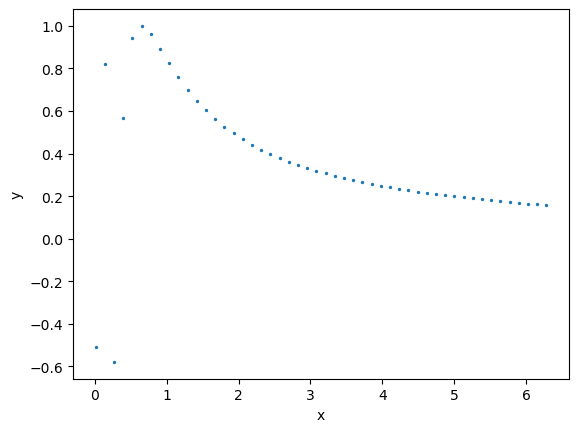

In [25]:
# part a
# define the function
def f(x):
    return np.sin(1 / x)

# defining constants
a = 0.01
b = 2 * np.pi

# create an array for x values with 50 points
x_vals = np.linspace(a, b, 50)

# create an array of y values
y_vals = []
for x in x_vals:
    y_vals.append(f(x))
y_vals = np.array(y_vals)

# make the plot
plt.scatter(x_vals, y_vals, s=2)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


Pulled the same code from problem 2 part a, I just changed the function being defined and the bounds a and b to be consistent with the problem given. 
The function is not very smooth. I don't think the GQ method will be very accurate right away at all.

In [31]:
# part c
# control the while loop
runCalc = True

# constants
a = 0.01
b = 2 * np.pi
N = 5

# finding the base case
x, w = gaussxw(N)

# map to required integration domain
xk = 0.5*(b-a)*x + 0.5*(b+a)
wk = 0.5*(b-a)*w

# apply gaussian quadrature
s1 = 0.0
for k in range(N):
    s1+= wk[k] * f(xk[k])


while runCalc:
    N *= 2

    x, w = gaussxw(N)

    # map to required integration domain
    xk = 0.5*(b-a)*x + 0.5*(b+a)
    wk = 0.5*(b-a)*w

    # apply gaussian quadrature
    s2 = 0.0
    for k in range(N):
        s2+= wk[k] * f(xk[k])

    # calculate errors
    delta = np.abs(s2-s1)
    
    # print results
    print("Result of the integral:", s2)
    print("Estimation Error:", delta)

    # setting values for the next error calc
    s1 = s2

    # conditional to break the loop
    if delta <= 1e-1:
        runCalc = False


print("Number of points:",N)


Result of the integral: 2.1795836819165104
Estimation Error: 0.3465191379178507
Result of the integral: 2.3948584800669477
Estimation Error: 0.21527479815043726
Result of the integral: 2.3031574328396247
Estimation Error: 0.09170104722732297
Number of points: 40


I don't have the patience to let this run for any reasonable error value. I'm pretty sure the code works properly? 

I used the same principle as problem 2 part c to find the GQ within the while loop. I did have to establish a 'base case' outside of the while loop to make sure my error calculations would work for the first iteration of the while loop. There is most likely a better way to do that, I'm just not sure what it may be unless I just assume the first iteration will not fit the function very well, and have s1 equal to zero when initializing constants.

## Infinite integrals (22 pts)

Let's evaluate the integral: 

$$ \int_0^\infty \frac{x^2}{\sqrt{x}}e^{-x}dx $$

I don't want to do this by hand, so let's do it computationally. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define the variable substitution you will make for to solve this problem. This should be done in markdown using LaTex formatting. 

In [ ]:
# Ran out of time :(

#### Step 2: Define the function to use in the next step for integration

In [ ]:
# Ran out of time :(

#### Step 3: Evaluate the integral using Gaussian Quadrature with 20 sample points

In [ ]:
# Ran out of time :(

#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{3\sqrt{\pi}}{4}$

In [ ]:
# Ran out of time :(

## Multiple integrals (22 pts)

Let's find the mass of a metal plate that is 3 meters wide (in the $x$ direction) and 2 meters tall ($y$ direction), with a nonuniform density of (in kg/$\text{m}^2$)

$$ \sigma(x,y) = (\sin(\pi x)+1)y $$

Hint 1: the total mass is given by: $$M = \iint_R \sigma(x,y) \hspace{1mm} dA$$

*Note: don't forget to put brief comments in your code*

#### Step 1: Write the full equation for the double integral in markdown. (Hint: you'll need to swithch the cell to markdown and then you can use some of my latex coding from the cell above this)

In [ ]:
# Ran out of time :(

#### Step 2: Define the function to use in the next step for integration

In [ ]:
# Ran out of time :(

#### Step 3: Evaluate the double integral using double Gaussian quadrature for 100 sample points along each axis. 

In [ ]:
# Ran out of time :(

#### Step 4: Include a markdown explaining the process and result. Include how your answer compares to the answer of $\frac{4}{\pi}+6 \simeq 7.2732395$

In [ ]:
# Ran out of time :(